# CGR Crash Data — Exploratory Data Analysis

Dataset: `data/CGR_Crash_Data.csv`

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA = Path("../data/raw/CGR_Crash_Data.csv")

## 1. Load & Overview

In [4]:
df = pd.read_csv(DATA, low_memory=False)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (74309, 142)


,X,Y,OBJECTID,ROADSOFTID,BIKE,CITY,COUNTY,CRASHDATE,CRASHSEVER,CRASHTYPE,...,RDLGLCODE,RDNFC,RDNFCCODE,RDNUMLANES,RDSUBTYPDS,RDSUBTYPE,RDSURFTYPE,RDUSRINVID,RDWIDTH,FRAMEWORK
0,-85.650003,42.919854,1,2589528,No,Grand Rapids,Kent,2008/06/16,Property Damage Only,Backing,...,5,Local,7,2,Asphalt-Standard,35,Asphalt,,26.0,17
1,-85.625665,42.924710,2,2593183,No,Grand Rapids,Kent,2008/08/30,Property Damage Only,Fixed Object,...,5,Local,7,2,Asphalt-Standard,35,Asphalt,,26.0,17
2,-85.655282,43.000972,3,2582102,No,Grand Rapids,Kent,2008/02/13,Property Damage Only,Other Driveway,...,5,Local,7,2,Asphalt-Standard,35,Asphalt,,29.0,17


In [5]:
df.dtypes.value_counts()

object     109
int64       28
float64      5
Name: count, dtype: int64

In [6]:
# Null rates — show only columns with any nulls
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
null_pct[null_pct > 0].to_frame("null_%").style.background_gradient(cmap="Reds")

,null_%
TRAFCTLDEV,57.015974
D2HAZACT,56.565154
D1HAZACT,30.817263
D3HAZACT,6.373387
V1WIMPCTPT,3.123444
V2WIMPCTPT,3.041354
V3WIMPCTPT,0.302790


In [7]:
# Parse date
df["CRASHDATE"] = pd.to_datetime(df["CRASHDATE"], errors="coerce")

# Numeric driver age — replace sentinel 999 with NaN
for col in ["DRIVER1AGE", "DRIVER2AGE", "DRIVER3AGE"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").replace(999, np.nan)

print("Date range:", df["CRASHDATE"].min(), "→", df["CRASHDATE"].max())

Date range: 2008-01-01 00:00:00 → 2017-12-31 00:00:00


## 2. Crash Severity Distribution

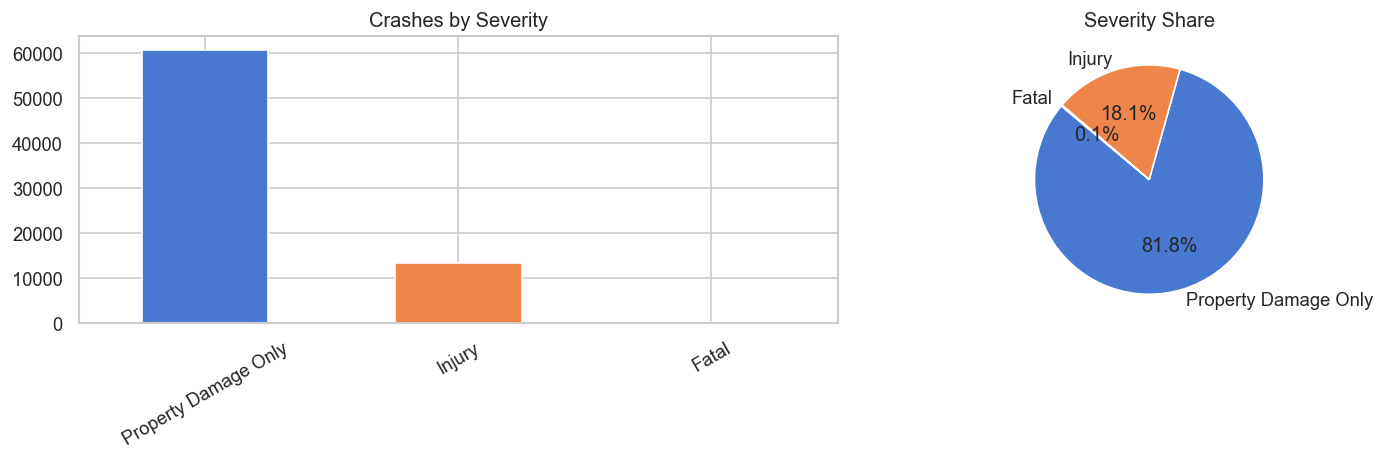

In [8]:
sev_order = df["CRASHSEVER"].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sev_counts = df["CRASHSEVER"].value_counts()
sev_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted", len(sev_counts)))
axes[0].set_title("Crashes by Severity")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

axes[1].pie(sev_counts, labels=sev_counts.index, autopct="%1.1f%%", startangle=140)
axes[1].set_title("Severity Share")

plt.tight_layout()
plt.show()

## 3. Temporal Patterns

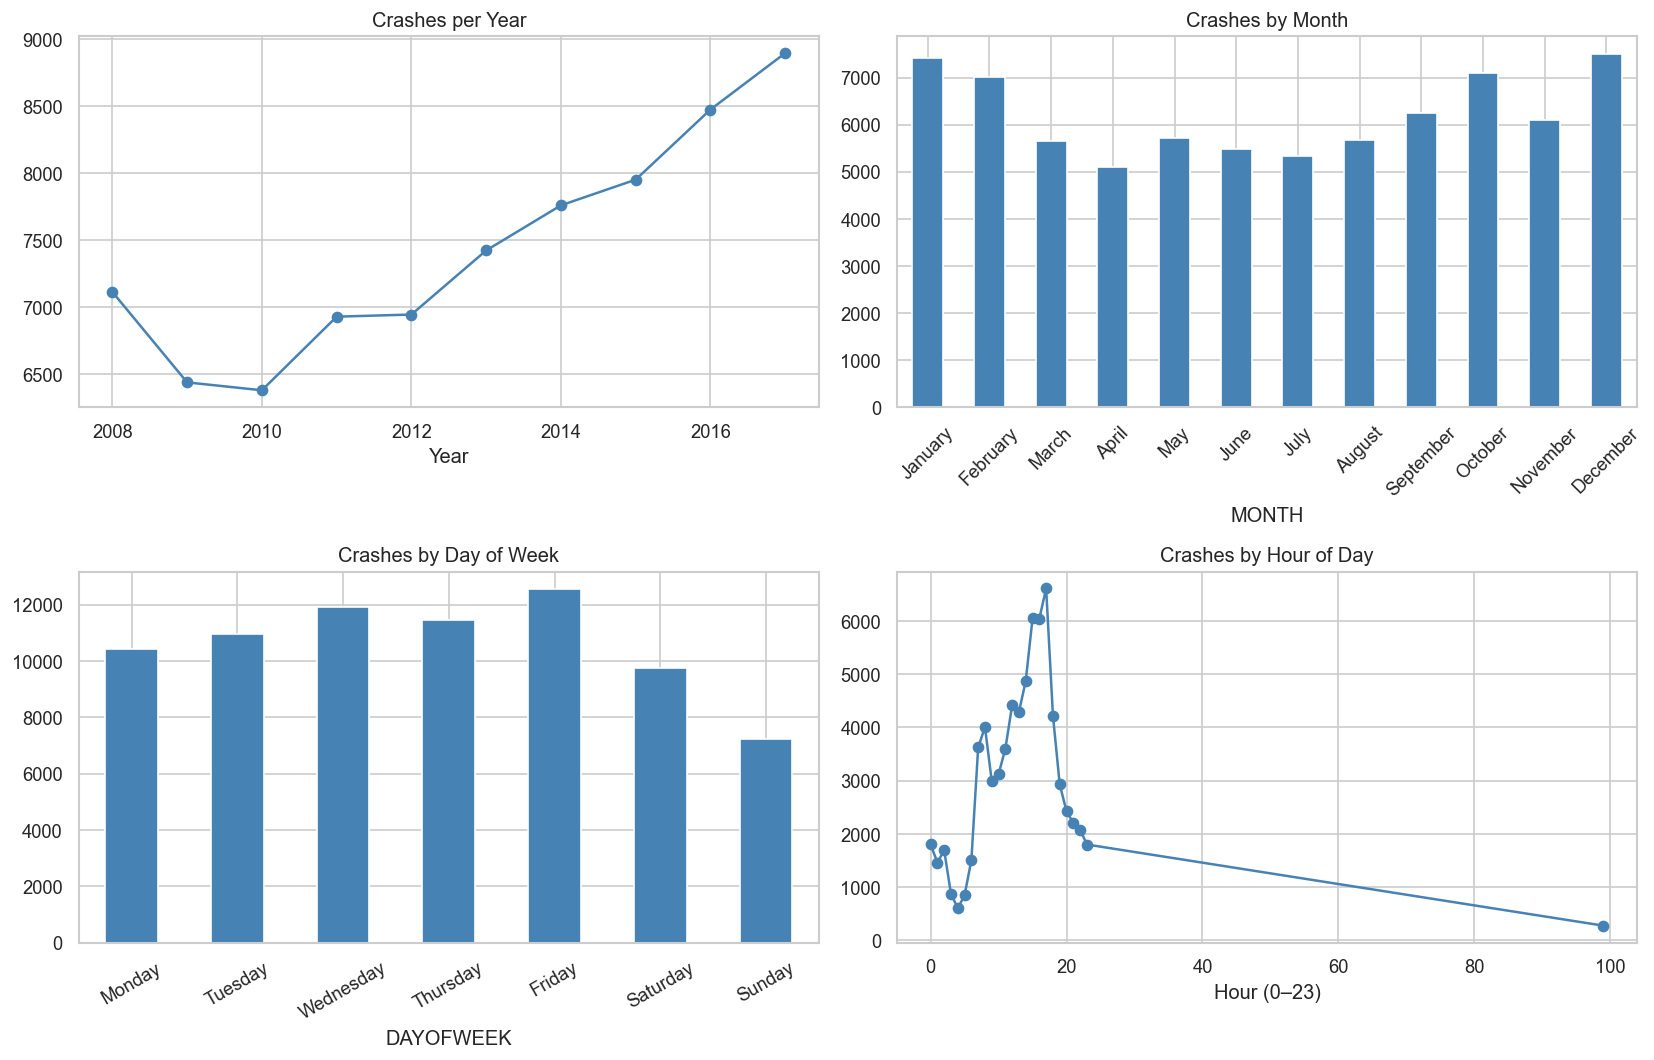

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Crashes per year
df["YEAR"].value_counts().sort_index().plot(ax=axes[0, 0], marker="o", color="steelblue")
axes[0, 0].set_title("Crashes per Year")
axes[0, 0].set_xlabel("Year")

# Crashes per month
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
month_counts = df["MONTH"].value_counts().reindex(month_order)
month_counts.plot(kind="bar", ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Crashes by Month")
axes[0, 1].tick_params(axis="x", rotation=45)

# Crashes by day of week
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = df["DAYOFWEEK"].value_counts().reindex(dow_order)
dow_counts.plot(kind="bar", ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Crashes by Day of Week")
axes[1, 0].tick_params(axis="x", rotation=30)

# Crashes by hour
df["HOUR"].value_counts().sort_index().plot(ax=axes[1, 1], marker="o", color="steelblue")
axes[1, 1].set_title("Crashes by Hour of Day")
axes[1, 1].set_xlabel("Hour (0–23)")

plt.tight_layout()
plt.show()

## 4. Environmental & Road Conditions

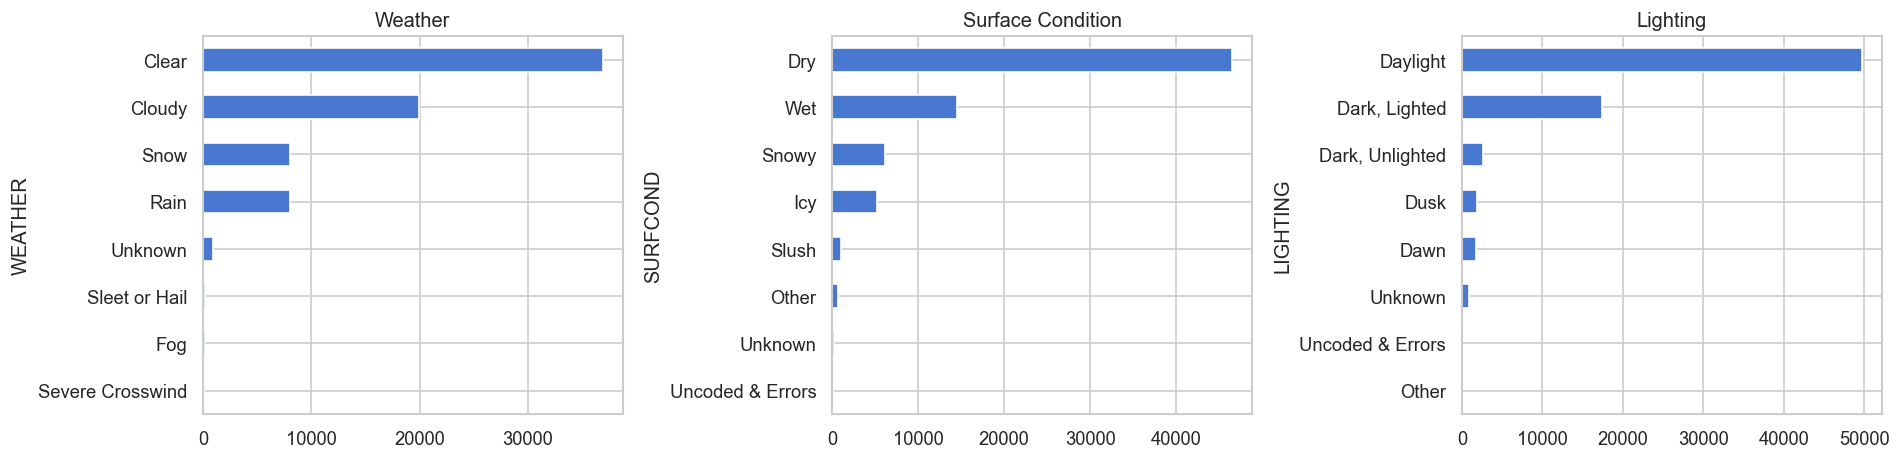

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(
    axes,
    ["WEATHER", "SURFCOND", "LIGHTING"],
    ["Weather", "Surface Condition", "Lighting"]
):
    top = df[col].value_counts().head(8)
    top.plot(kind="barh", ax=ax)
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

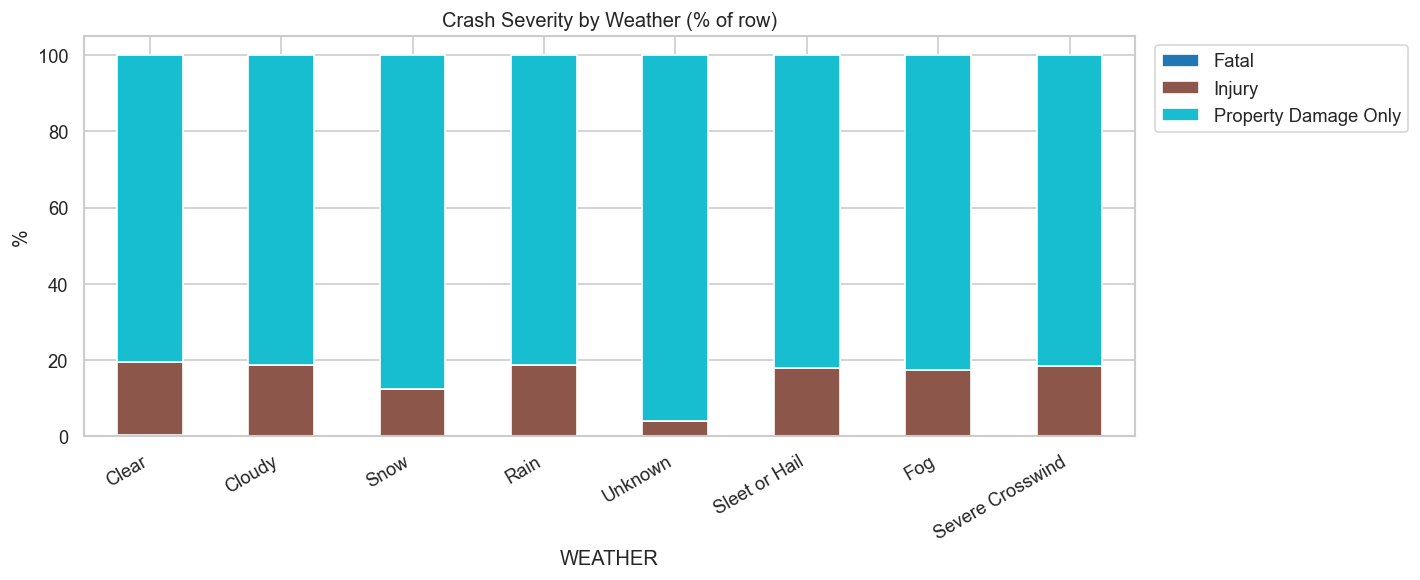

In [11]:
# Severity breakdown by weather
sev_weather = pd.crosstab(df["WEATHER"], df["CRASHSEVER"], normalize="index") * 100
sev_weather = sev_weather.loc[df["WEATHER"].value_counts().head(8).index]

sev_weather.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab10")
plt.title("Crash Severity by Weather (% of row)")
plt.ylabel("%")
plt.xticks(rotation=30, ha="right")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Injury & Fatality Analysis

In [12]:
print(df[["NUMOFINJ", "NUMOFKILL", "NUMOFOCCUP", "NUMOFVEHIC"]].describe())

           NUMOFINJ     NUMOFKILL    NUMOFOCCUP    NUMOFVEHIC
count  74309.000000  74309.000000  74309.000000  74309.000000
mean       0.230887      0.001467      2.320984      1.940398
std        0.559503      0.039653      2.114018      0.544675
min        0.000000      0.000000      0.000000      1.000000
25%        0.000000      0.000000      1.000000      2.000000
50%        0.000000      0.000000      2.000000      2.000000
75%        0.000000      0.000000      3.000000      2.000000
max       10.000000      2.000000     99.000000     12.000000


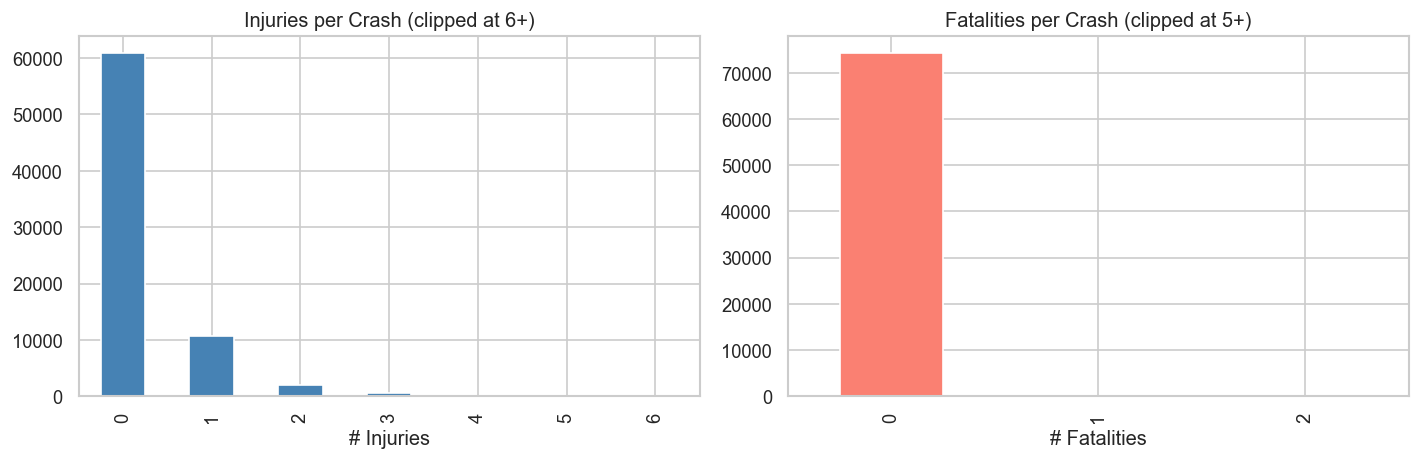

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["NUMOFINJ"].clip(upper=6).value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Injuries per Crash (clipped at 6+)")
axes[0].set_xlabel("# Injuries")

df["NUMOFKILL"].clip(upper=5).value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="salmon"
)
axes[1].set_title("Fatalities per Crash (clipped at 5+)")
axes[1].set_xlabel("# Fatalities")

plt.tight_layout()
plt.show()

## 6. Driver Demographics

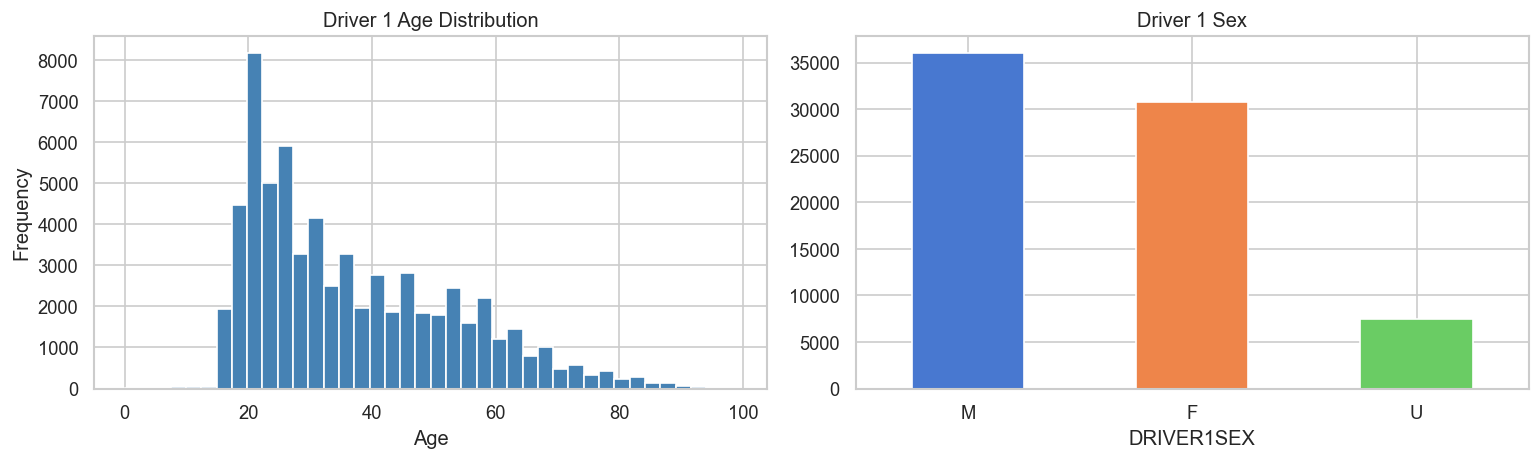

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["DRIVER1AGE"].dropna().plot(
    kind="hist", bins=40, ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Driver 1 Age Distribution")
axes[0].set_xlabel("Age")

df["DRIVER1SEX"].value_counts().plot(kind="bar", ax=axes[1], color=sns.color_palette("muted", 3))
axes[1].set_title("Driver 1 Sex")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

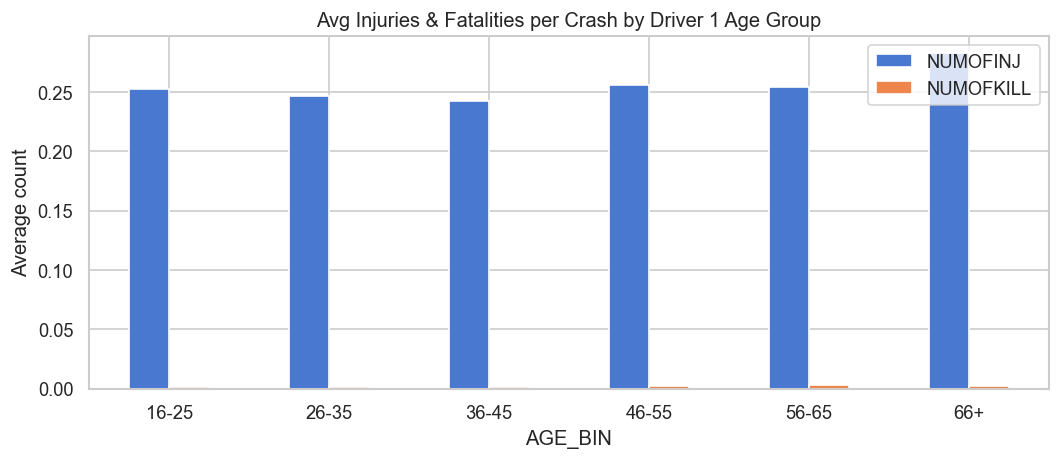

In [15]:
# Average severity score proxy: fatalities + 0.5*injuries by age bucket
df["AGE_BIN"] = pd.cut(df["DRIVER1AGE"], bins=[15, 25, 35, 45, 55, 65, 100],
                        labels=["16-25", "26-35", "36-45", "46-55", "56-65", "66+"])
age_sev = df.groupby("AGE_BIN", observed=True)[["NUMOFINJ", "NUMOFKILL"]].mean()
age_sev.plot(kind="bar", figsize=(9, 4))
plt.title("Avg Injuries & Fatalities per Crash by Driver 1 Age Group")
plt.ylabel("Average count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Special Crash Categories

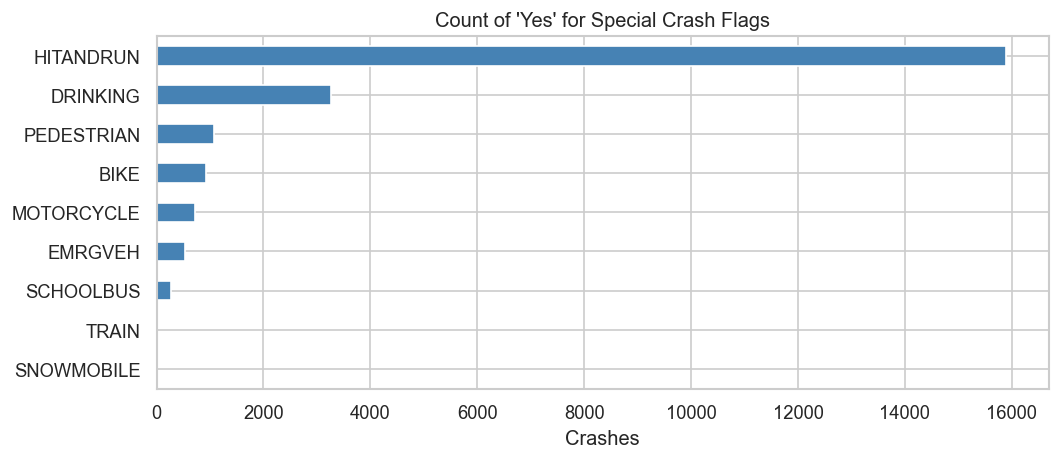

In [16]:
flags = ["BIKE", "PEDESTRIAN", "MOTORCYCLE", "HITANDRUN", "DRINKING",
         "SCHOOLBUS", "EMRGVEH", "SNOWMOBILE", "TRAIN"]

# Normalise to Yes/No
flag_yes = {col: (df[col].str.contains("Yes", na=False, case=False)).sum() for col in flags}
flag_series = pd.Series(flag_yes).sort_values(ascending=True)

flag_series.plot(kind="barh", figsize=(9, 4), color="steelblue")
plt.title("Count of 'Yes' for Special Crash Flags")
plt.xlabel("Crashes")
plt.tight_layout()
plt.show()

## 8. Crash Type & Contributing Factors

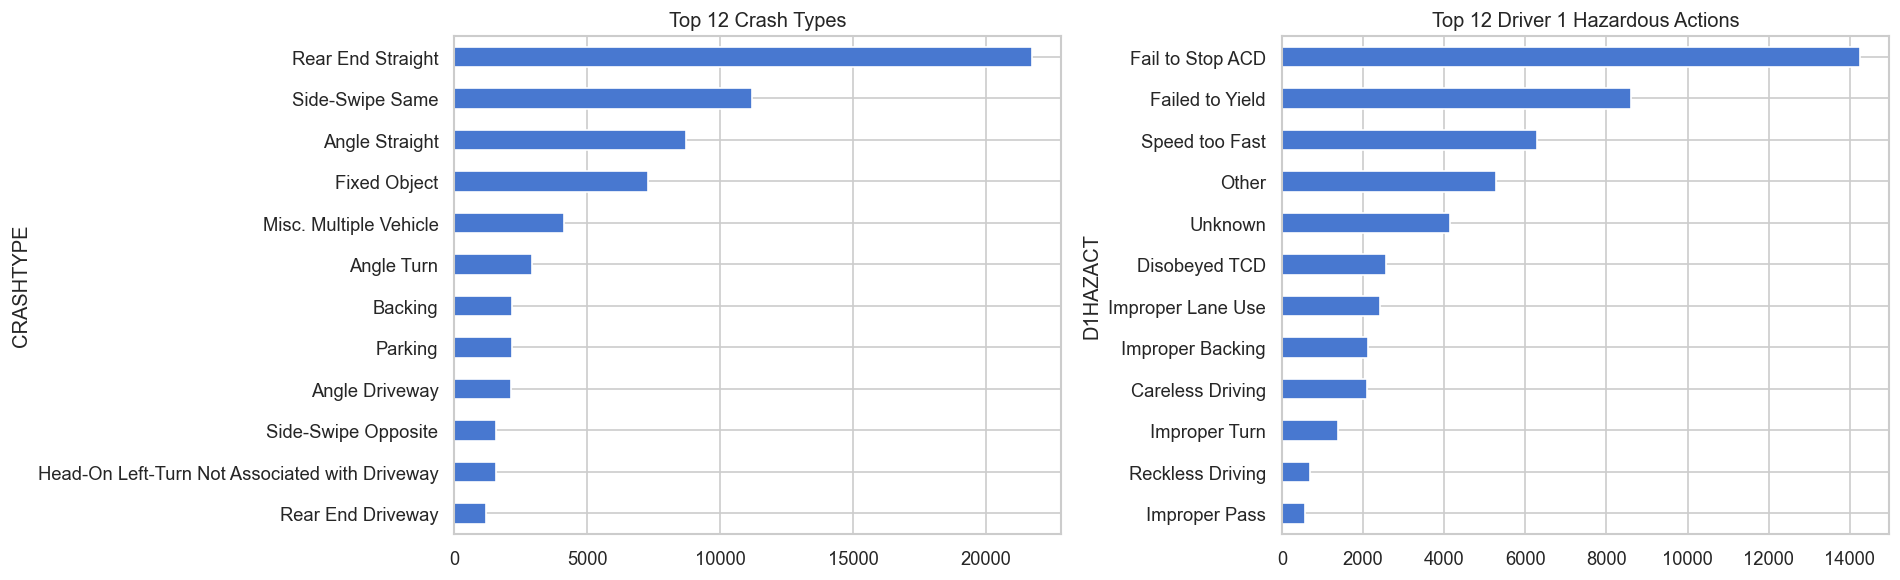

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df["CRASHTYPE"].value_counts().head(12).plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 12 Crash Types")
axes[0].invert_yaxis()

df["D1HAZACT"].value_counts().head(12).plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 12 Driver 1 Hazardous Actions")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Geographic Overview (Lat/Lon Scatter)

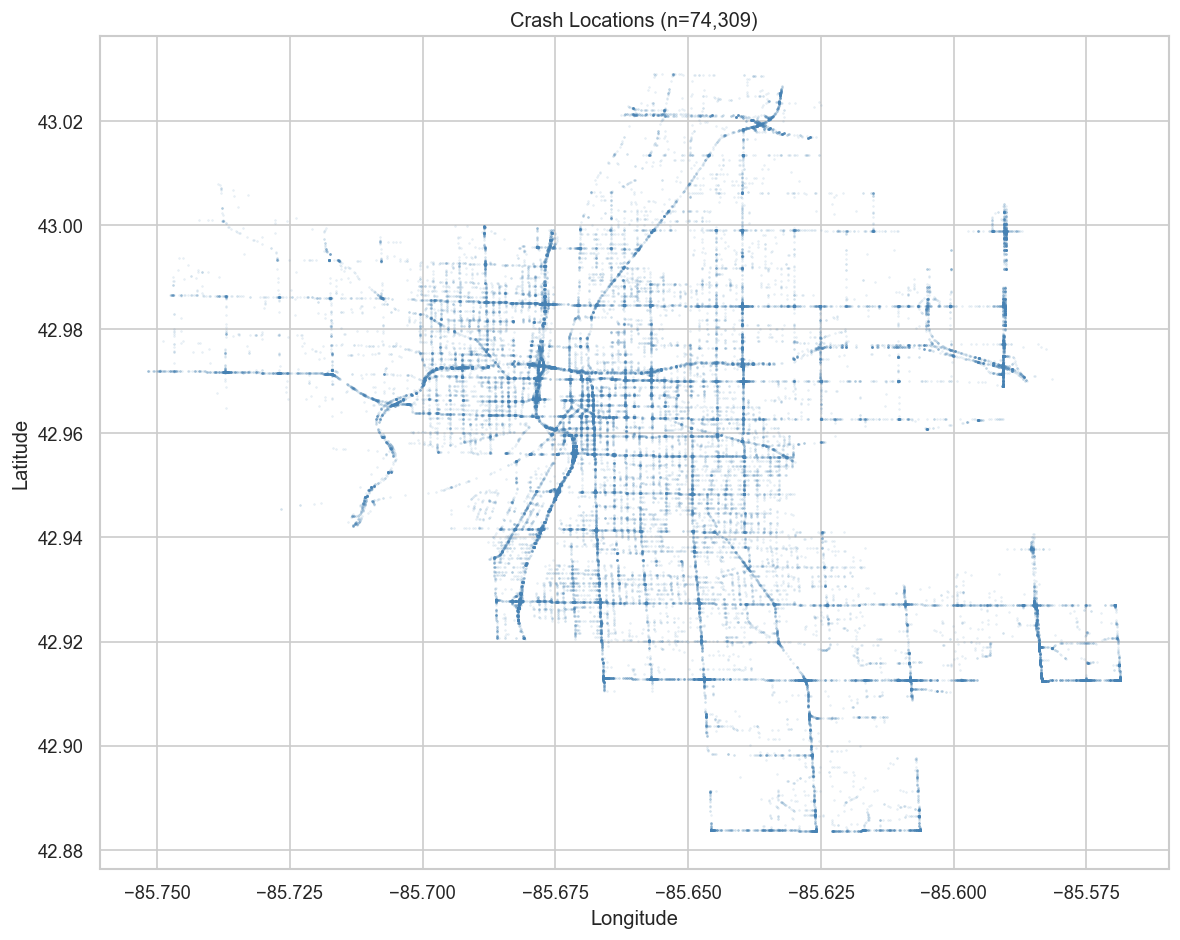

In [18]:
# Remove obvious outliers (points far outside Michigan)
geo = df[(df["X"].between(-90, -82)) & (df["Y"].between(41, 48))].copy()

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(geo["X"], geo["Y"], s=0.2, alpha=0.15, color="steelblue")
ax.set_title(f"Crash Locations (n={len(geo):,})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 10. Speed Limit vs Severity

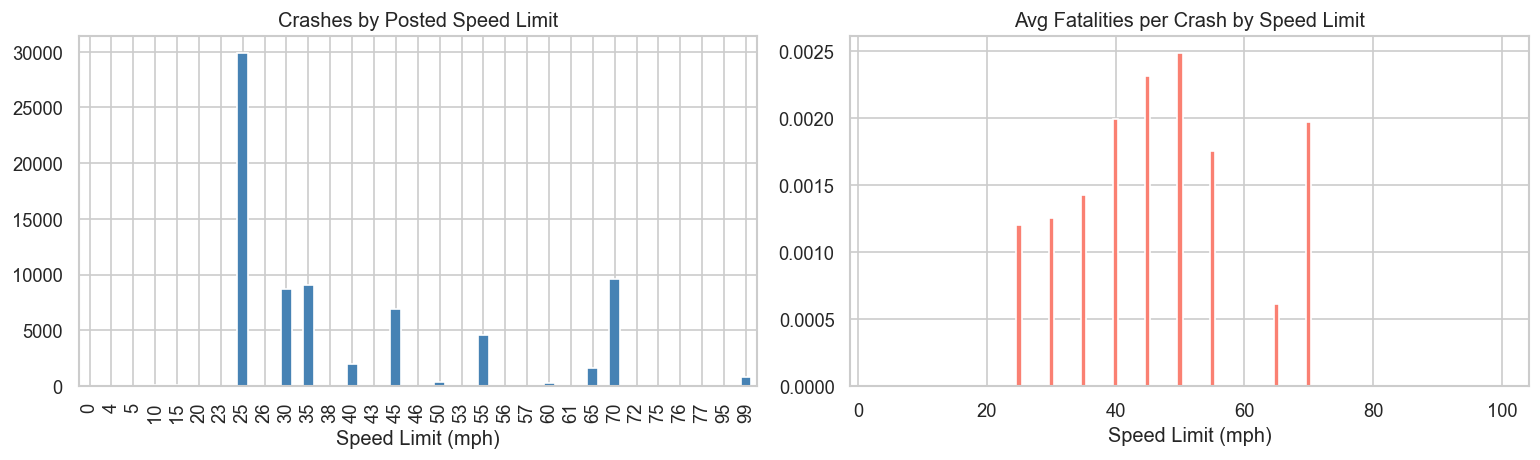

In [19]:
speed_sev = df.groupby("SPEEDLIMIT")["NUMOFKILL"].mean().reset_index()
speed_sev = speed_sev[speed_sev["SPEEDLIMIT"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["SPEEDLIMIT"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Crashes by Posted Speed Limit")
axes[0].set_xlabel("Speed Limit (mph)")

axes[1].bar(speed_sev["SPEEDLIMIT"], speed_sev["NUMOFKILL"], color="salmon")
axes[1].set_title("Avg Fatalities per Crash by Speed Limit")
axes[1].set_xlabel("Speed Limit (mph)")

plt.tight_layout()
plt.show()

## 11. Correlation Heatmap (Numeric Columns)

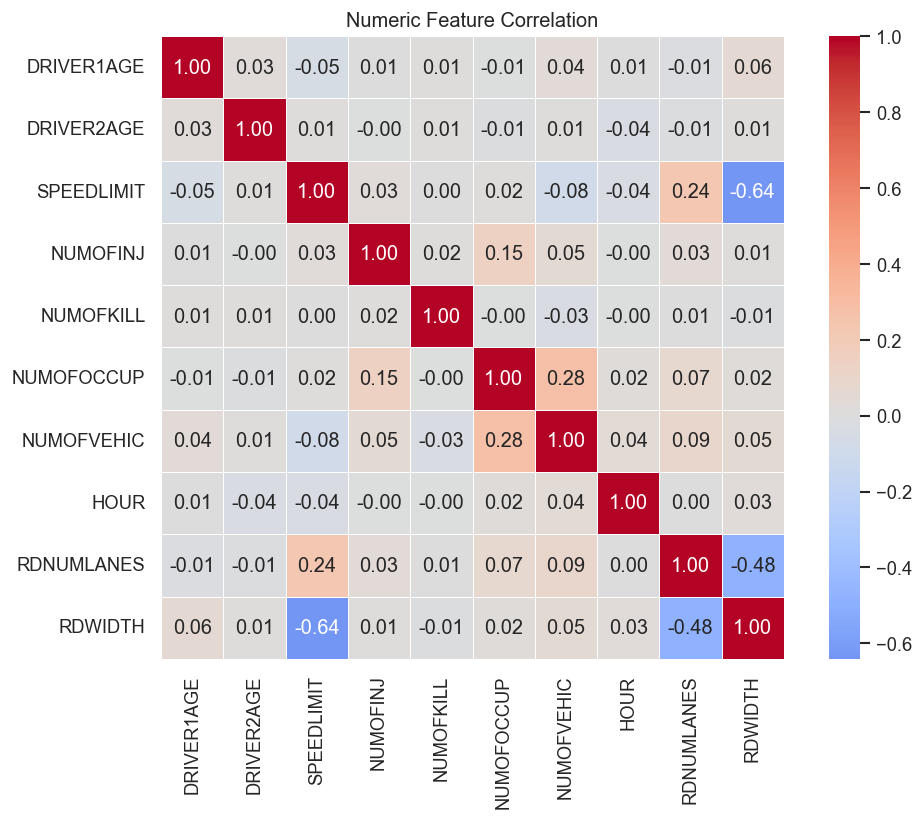

In [20]:
num_cols = ["DRIVER1AGE", "DRIVER2AGE", "SPEEDLIMIT", "NUMOFINJ",
            "NUMOFKILL", "NUMOFOCCUP", "NUMOFVEHIC", "HOUR", "RDNUMLANES", "RDWIDTH"]

corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Numeric Feature Correlation")
plt.tight_layout()
plt.show()

## 12. Mutual Information Heatmap

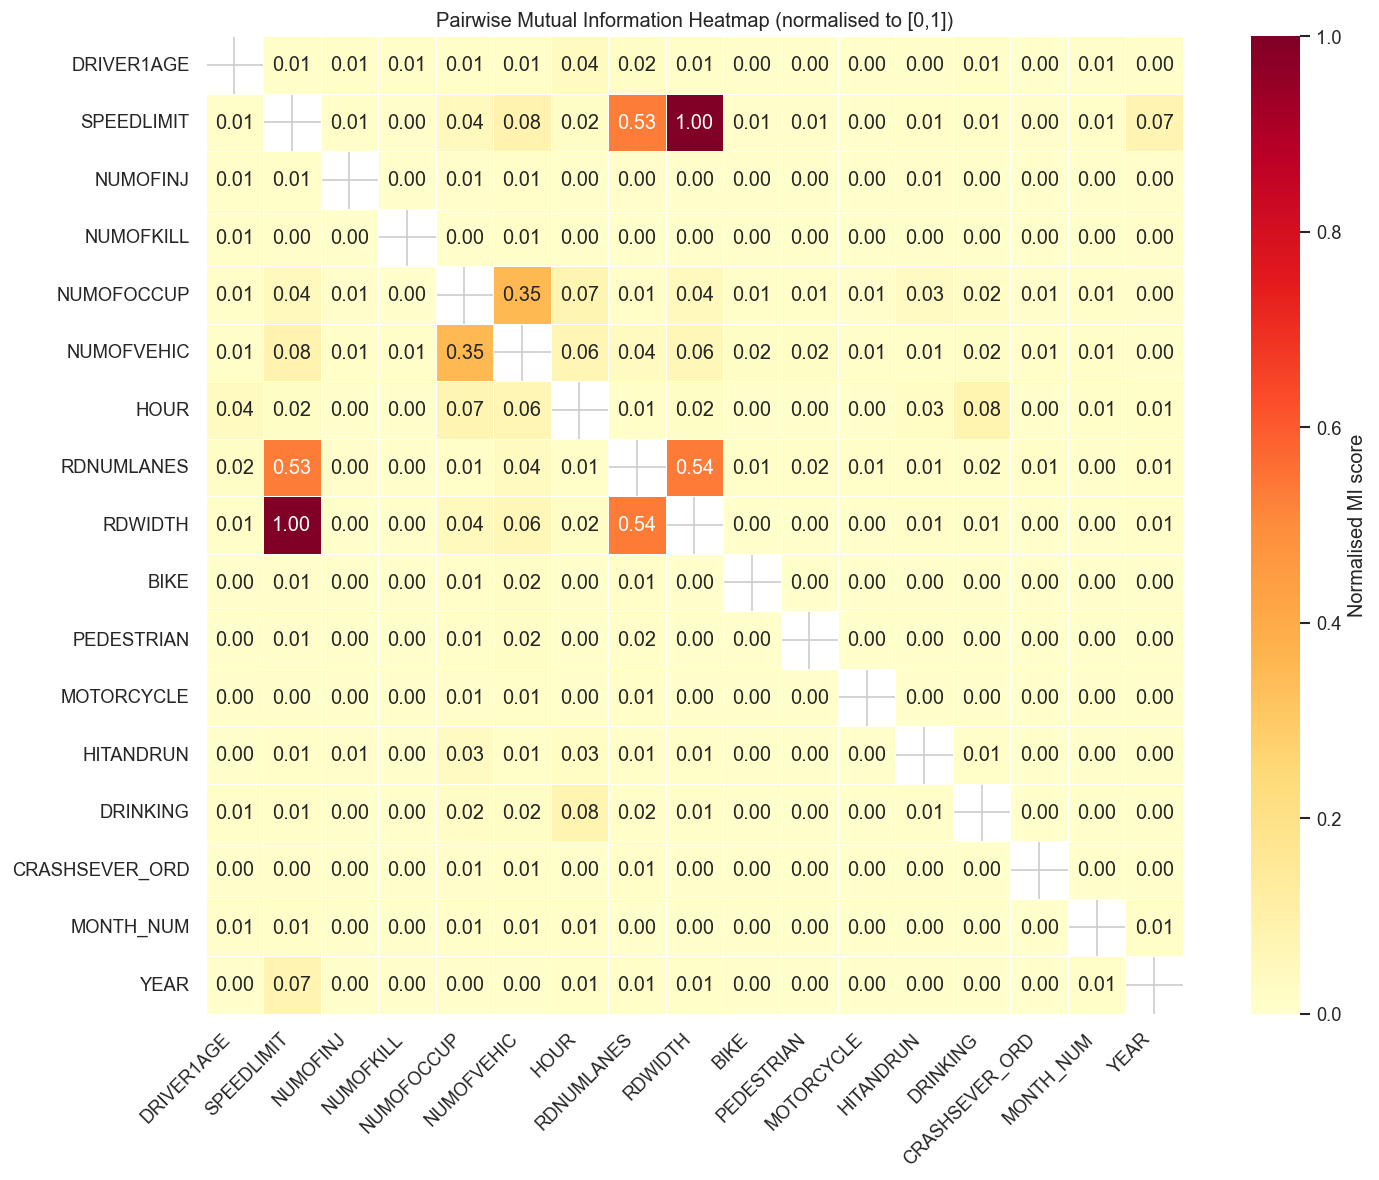

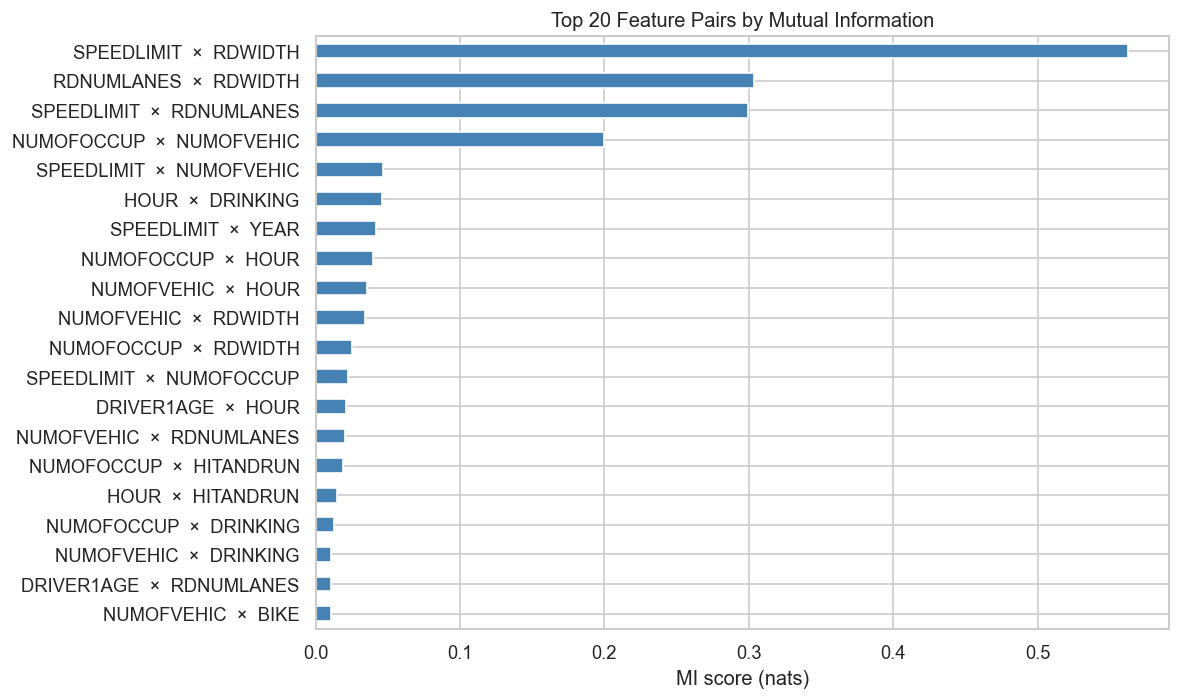

In [21]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

# --- Feature matrix ---
cont_cols = ["DRIVER1AGE", "SPEEDLIMIT", "NUMOFINJ", "NUMOFKILL",
             "NUMOFOCCUP", "NUMOFVEHIC", "HOUR", "RDNUMLANES", "RDWIDTH"]
flag_cols  = ["BIKE", "PEDESTRIAN", "MOTORCYCLE", "HITANDRUN", "DRINKING"]

mi_df = df[cont_cols].copy()

# Binary flags → 0/1
for col in flag_cols:
    mi_df[col] = df[col].str.contains("Yes", na=False, case=False).astype(int)

# Crash severity → ordinal integer
sev_map = {"Property Damage Only": 0, "Non-Incapacitating Injury": 1,
           "Incapacitating Injury": 2, "Fatal Injury": 3}
mi_df["CRASHSEVER_ORD"] = df["CRASHSEVER"].map(sev_map)

# Temporal
mi_df["MONTH_NUM"] = pd.to_datetime(df["CRASHDATE"], errors="coerce").dt.month
mi_df["YEAR"]      = df["YEAR"]

mi_df = mi_df.dropna()

# Track which features are discrete (classif target) vs continuous (regression target)
disc_cols  = set(flag_cols + ["CRASHSEVER_ORD", "MONTH_NUM", "YEAR"])
features   = mi_df.columns.tolist()
is_discrete = np.array([f in disc_cols for f in features])

# --- Pairwise MI matrix ---
# Use mutual_info_classif when the *target* is discrete, regression otherwise.
# Pass discrete_features mask for the *inputs* in both cases.
mi_matrix = pd.DataFrame(
    np.zeros((len(features), len(features))), index=features, columns=features
)

for i, target in enumerate(features):
    X      = mi_df.drop(columns=[target])
    y      = mi_df[target]
    x_disc = np.delete(is_discrete, i)   # mask for inputs (drop current target)

    if is_discrete[i]:
        scores = mutual_info_classif(X, y, discrete_features=x_disc, random_state=42)
    else:
        scores = mutual_info_regression(X, y, discrete_features=x_disc, random_state=42)

    for feat, score in zip(X.columns, scores):
        mi_matrix.loc[target, feat] = score

# Symmetrize: take element-wise max of (i,j) and (j,i)
mi_sym_arr = np.maximum(mi_matrix.to_numpy(), mi_matrix.to_numpy().T).astype(float, copy=True)
np.fill_diagonal(mi_sym_arr, np.nan)   # diagonal undefined — hide it

mi_sym = pd.DataFrame(mi_sym_arr, index=features, columns=features)

mi_norm = mi_sym / np.nanmax(mi_sym.values)

# --- Heatmap ---
plt.figure(figsize=(13, 10))
sns.heatmap(
    mi_norm,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.4,
    square=True,
    vmin=0, vmax=1,
    cbar_kws={"label": "Normalised MI score"},
    mask=np.isnan(mi_norm),
)
plt.title("Pairwise Mutual Information Heatmap (normalised to [0,1])")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Top-20 pairs ranked bar chart ---
pairs = (
    mi_sym.where(np.triu(np.ones(mi_sym.shape, dtype=bool), k=1))
          .stack()
          .sort_values(ascending=False)
          .head(20)
)
pairs.index = [f"{a}  ×  {b}" for a, b in pairs.index]

pairs.plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Pairs by Mutual Information")
plt.xlabel("MI score (nats)")
plt.tight_layout()
plt.show()

## 13. Composite Feature Ranking (vs Crash Severity)

,feature,dtype,null_%,variance_score,mi_score,composite
1,NUMOFOCCUP,numeric,0.0%,0.933,1.000,0.990
2,NUMOFUNINJ,numeric,0.0%,0.933,0.873,0.895
3,DRIVER3AGE,numeric,94.8%,0.407,0.409,0.373
4,RDWIDTH,numeric,0.0%,0.780,0.169,0.344
5,ROUTENUM,numeric,0.0%,1.000,0.000,0.250
6,CTRLSECT,numeric,0.0%,1.000,0.000,0.250
7,DRIVER2AGE,numeric,34.1%,0.416,0.104,0.206
8,DRIVER1AGE,numeric,14.0%,0.442,0.071,0.206
9,HOUR,numeric,0.0%,0.597,0.000,0.190
10,DAYOFMONTH,numeric,0.0%,0.560,0.000,0.184


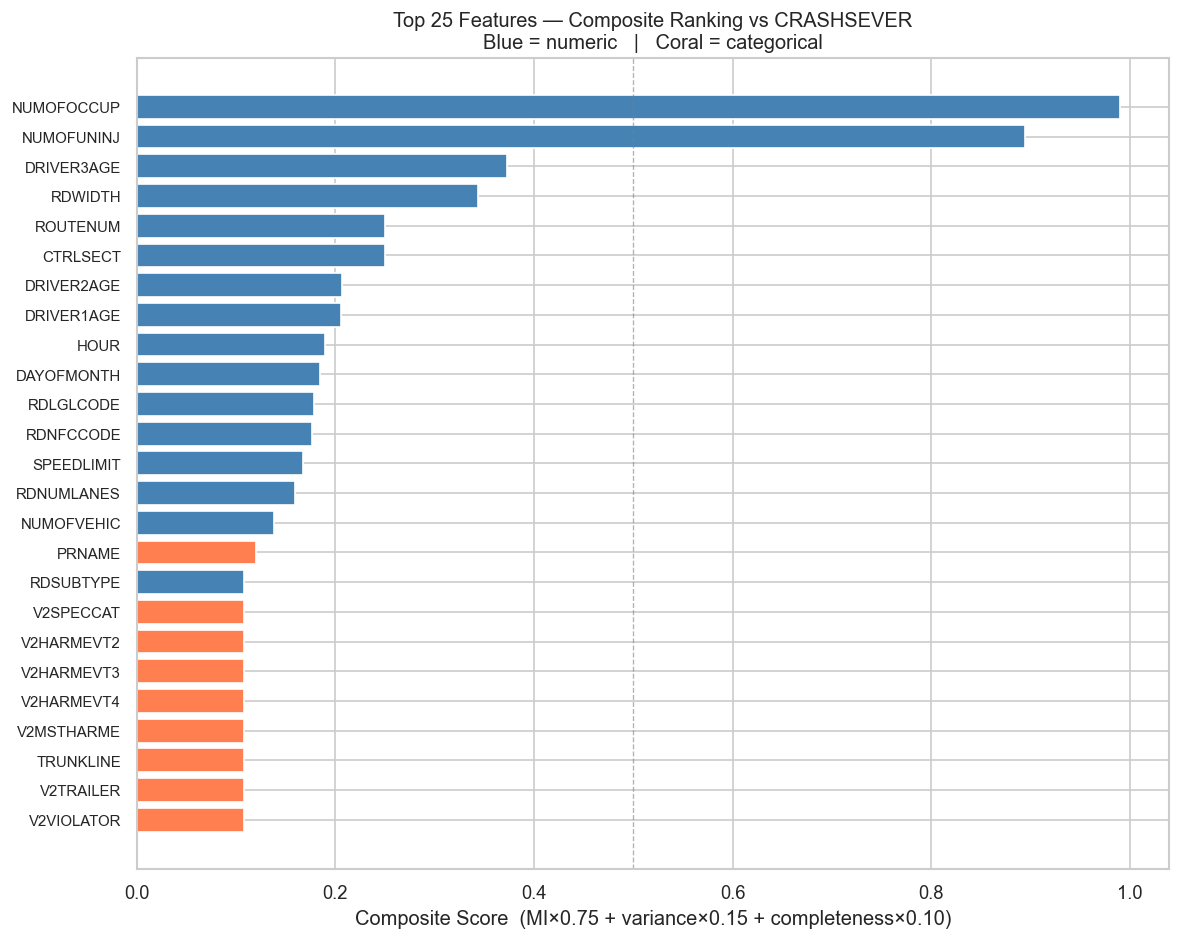


Total features scored: 129


In [22]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

# --- Target ---
sev_map = {"Property Damage Only": 0, "Non-Incapacitating Injury": 1,
           "Incapacitating Injury": 2, "Fatal Injury": 3}
y_sev = df["CRASHSEVER"].map(sev_map)
valid = y_sev.notna()
y_sev = y_sev[valid].astype(int)

# --- Feature matrix: all 142 columns minus identifiers / raw target ---
exclude = {
    "CRASHSEVER", "CRASHDATE",                          # target & raw date
    "OBJECTID", "ROADSOFTID", "FWSEGID", "UD10NUM",     # surrogate keys
    "RDUSRINVID", "PRNO", "INTERNAME",                   # road/location IDs
    "X", "Y", "CTRLMILEPT", "MILEPOINT", "REFDIST",     # coordinates & distances
}
feat_cols = [c for c in df.columns if c not in exclude]
df_feat   = df.loc[valid, feat_cols].copy()

num_feats = df_feat.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = df_feat.select_dtypes(exclude=[np.number]).columns.tolist()

# Ordinal-encode categoricals (unknown → -1)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
cat_enc = enc.fit_transform(df_feat[cat_feats].astype(str).fillna("__missing__"))
cat_enc_df = pd.DataFrame(cat_enc, columns=cat_feats, index=df_feat.index)

X = pd.concat([df_feat[num_feats].fillna(-1), cat_enc_df], axis=1)

# discrete_features: all categoricals + low-cardinality integer numerics
int_disc   = {c for c in num_feats if df_feat[c].nunique() < 50}
is_disc    = np.array([(c in cat_feats or c in int_disc) for c in X.columns])

# Single MI call across all features at once
mi_raw   = mutual_info_classif(X, y_sev, discrete_features=is_disc, random_state=42)
mi_series = pd.Series(mi_raw, index=X.columns)

# --- Per-feature metrics ---
records = []
for col in X.columns:
    orig      = df_feat[col]
    null_rate = orig.isna().mean()

    if col in num_feats:
        std   = orig.std()
        mean_ = orig.mean()
        var_score = min(1.0, std / abs(mean_)) if mean_ != 0 else min(1.0, std)
        dtype = "numeric"
    else:
        n_non_null = orig.notna().sum()
        ratio      = orig.nunique() / n_non_null if n_non_null > 0 else 0
        if ratio > 0.95 and n_non_null > 50:
            var_score = 0.05          # likely a unique ID column
        elif ratio < 0.01:
            var_score = 0.05          # near-constant
        else:
            var_score = min(1.0, ratio * 5)
        dtype = "categorical"

    records.append({
        "feature":        col,
        "dtype":          dtype,
        "null_rate":      round(null_rate, 4),
        "null_score":     round(1 - null_rate, 4),
        "variance_score": round(var_score, 4),
        "mi_raw":         round(mi_series[col], 6),
    })

ranking = pd.DataFrame(records)

# Normalise MI to [0, 1]
mi_max            = ranking["mi_raw"].max()
ranking["mi_norm"] = (ranking["mi_raw"] / mi_max).round(4) if mi_max > 0 else 0.0

# Composite score  (weights: null=0.10, variance=0.15, MI=0.75)
W_NULL, W_VAR, W_MI = 0.10, 0.15, 0.75
ranking["composite"] = (
    W_NULL * ranking["null_score"] +
    W_VAR  * ranking["variance_score"] +
    W_MI   * ranking["mi_norm"]
).round(4)

ranking = ranking.sort_values("composite", ascending=False).reset_index(drop=True)
ranking.index += 1   # 1-based rank

# --- Styled table: top 30 ---
display(
    ranking[["feature", "dtype", "null_rate", "variance_score", "mi_norm", "composite"]]
    .head(30)
    .rename(columns={"null_rate": "null_%", "mi_norm": "mi_score"})
    .style
    .background_gradient(subset=["mi_score", "composite"], cmap="YlOrRd")
    .format({"null_%": "{:.1%}", "variance_score": "{:.3f}",
             "mi_score": "{:.3f}", "composite": "{:.3f}"})
)

# --- Bar chart: top 25 ---
top25  = ranking.head(25)
colors = ["steelblue" if d == "numeric" else "coral" for d in top25["dtype"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top25)), top25["composite"].iloc[::-1].values, color=list(reversed(colors)))
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25["feature"].iloc[::-1].values, fontsize=9)
ax.set_xlabel("Composite Score  (MI×0.75 + variance×0.15 + completeness×0.10)")
ax.set_title("Top 25 Features — Composite Ranking vs CRASHSEVER\n"
             "Blue = numeric   |   Coral = categorical")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\nTotal features scored: {len(ranking)}")

## 14. Features with Most Impact on Fatal Crashes

Analyze which features are most predictive of Fatal crashes specifically (Fatal vs all other severities).

In [24]:
# Create binary target: Fatal vs Non-Fatal
df['is_fatal'] = (df['CRASHSEVER'] == 'Fatal').astype(int)

print(f"Fatal crashes: {df['is_fatal'].sum():,} ({df['is_fatal'].mean()*100:.2f}%)")
print(f"Non-fatal crashes: {(~df['is_fatal'].astype(bool)).sum():,} ({(1-df['is_fatal'].mean())*100:.2f}%)")

# Select numeric features (excluding target, IDs, and coordinates)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['CRASHSEVER', 'is_fatal', 'OBJECTID', 'X', 'Y', 'ROADSOFTID', 
                'FWSEGID', 'UD10NUM', 'RDUSRINVID', 'PRNO', 'CTRLMILEPT', 
                'MILEPOINT', 'REFDIST']
numeric_features = [col for col in numeric_cols if col not in exclude_cols and col in df.columns]

print(f"\nAnalyzing {len(numeric_features)} numeric features")

Fatal crashes: 105 (0.14%)
Non-fatal crashes: 74,204 (99.86%)

Analyzing 23 numeric features


In [25]:
# Compute correlations with Fatal crashes
fatal_correlations = df[numeric_features + ['is_fatal']].corr()['is_fatal'].drop('is_fatal')
fatal_corr_abs = fatal_correlations.abs().sort_values(ascending=False)

print("Top 20 features by absolute correlation with Fatal crashes:\n")
for feat in fatal_corr_abs.head(20).index:
    corr_val = fatal_correlations[feat]
    print(f"{feat:20s}  {corr_val:7.4f}  {'↑' if corr_val > 0 else '↓'}")

print(f"\nCorrelation range: [{fatal_correlations.min():.4f}, {fatal_correlations.max():.4f}]")

Top 20 features by absolute correlation with Fatal crashes:

NUMOFKILL              0.9834  ↑
NOATYPEINJ             0.0562  ↑
NUMOFVEHIC            -0.0353  ↓
NUMOFUNINJ            -0.0257  ↓
NUMOFINJ               0.0171  ↑
DRIVER3AGE            -0.0155  ↓
DRIVER1AGE             0.0147  ↑
RDWIDTH               -0.0120  ↓
DRIVER2AGE             0.0117  ↑
NOBTYPEINJ             0.0104  ↑
RDLGLCODE             -0.0102  ↓
RDNFCCODE             -0.0097  ↓
RDNUMLANES             0.0077  ↑
CTRLSECT               0.0059  ↑
SPEEDLIMIT             0.0052  ↑
ROUTENUM               0.0050  ↑
HOUR                  -0.0048  ↓
RDSUBTYPE              0.0031  ↑
NUMOFOCCUP            -0.0030  ↓
YEAR                   0.0010  ↑

Correlation range: [-0.0353, 0.9834]


In [26]:
# Compute Mutual Information for Fatal crashes
from sklearn.feature_selection import mutual_info_classif

# Prepare data - fill NaNs with median
X_fatal = df[numeric_features].fillna(df[numeric_features].median())
y_fatal = df['is_fatal']

# Compute MI scores
fatal_mi_scores = mutual_info_classif(X_fatal, y_fatal, random_state=42, n_neighbors=5)
fatal_mi_series = pd.Series(fatal_mi_scores, index=numeric_features).sort_values(ascending=False)

print("Top 20 features by Mutual Information with Fatal crashes:\n")
for feat in fatal_mi_series.head(20).index:
    mi_val = fatal_mi_series[feat]
    print(f"{feat:20s}  {mi_val:.6f}")

print(f"\nMI range: [{fatal_mi_series.min():.6f}, {fatal_mi_series.max():.6f}]")

Top 20 features by Mutual Information with Fatal crashes:

NUMOFKILL             0.010691
FRAMEWORK             0.010561
DRIVER3AGE            0.008870
RDNUMLANES            0.006161
NUMOFVEHIC            0.004992
RDSUBTYPE             0.004322
RDLGLCODE             0.003761
NUMOFUNINJ            0.002116
RDNFCCODE             0.001845
SPEEDLIMIT            0.001632
NUMOFOCCUP            0.001553
YEAR                  0.000899
DRIVER2AGE            0.000790
HOUR                  0.000740
CTRLSECT              0.000671
ROUTENUM              0.000549
NOATYPEINJ            0.000468
DRIVER1AGE            0.000413
NUMOFINJ              0.000386
DAYOFMONTH            0.000339

MI range: [0.000107, 0.010691]


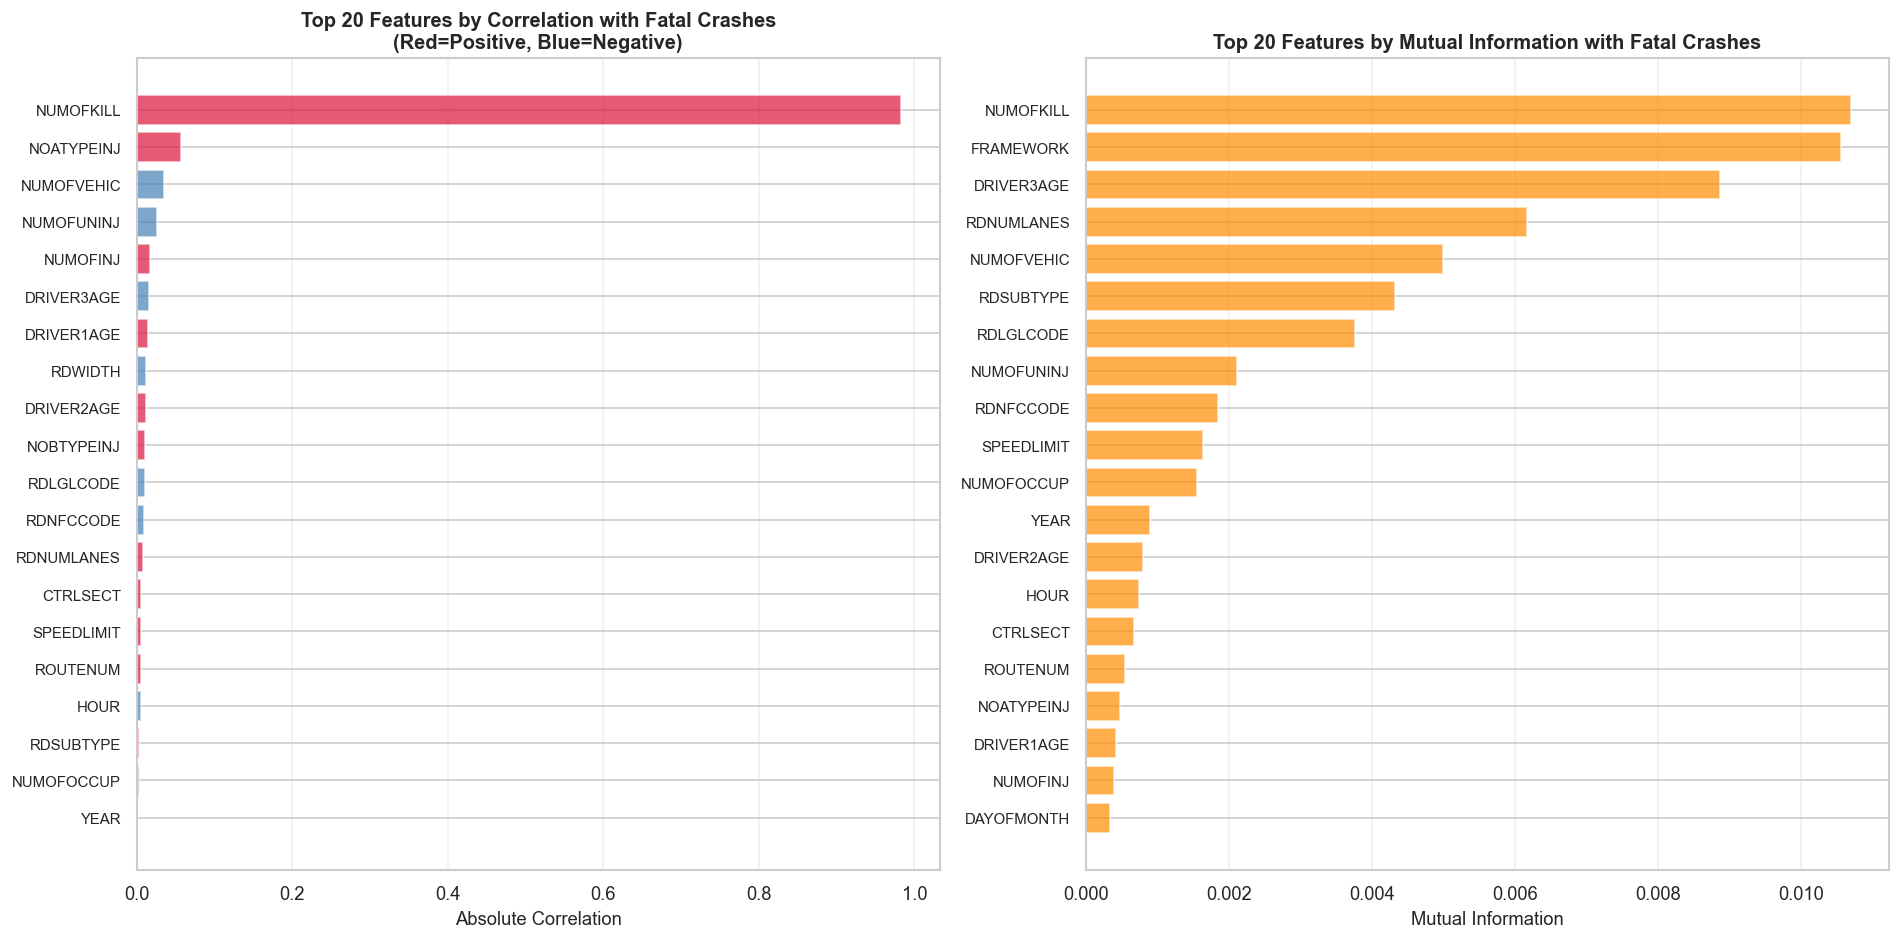

In [27]:
# Visualize top features for Fatal crashes
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 by correlation
top_corr_fatal = fatal_corr_abs.head(20).sort_values()
colors_corr = ['crimson' if fatal_correlations[f] > 0 else 'steelblue' for f in top_corr_fatal.index]
axes[0].barh(range(len(top_corr_fatal)), top_corr_fatal.values, color=colors_corr, alpha=0.7)
axes[0].set_yticks(range(len(top_corr_fatal)))
axes[0].set_yticklabels(top_corr_fatal.index, fontsize=9)
axes[0].set_xlabel('Absolute Correlation', fontsize=11)
axes[0].set_title('Top 20 Features by Correlation with Fatal Crashes\n(Red=Positive, Blue=Negative)', 
                  fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Top 20 by MI
top_mi_fatal = fatal_mi_series.head(20).sort_values()
axes[1].barh(range(len(top_mi_fatal)), top_mi_fatal.values, color='darkorange', alpha=0.7)
axes[1].set_yticks(range(len(top_mi_fatal)))
axes[1].set_yticklabels(top_mi_fatal.index, fontsize=9)
axes[1].set_xlabel('Mutual Information', fontsize=11)
axes[1].set_title('Top 20 Features by Mutual Information with Fatal Crashes', 
                  fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Compare feature values: Fatal vs Non-Fatal crashes
# Select top 15 features by MI
top_15_fatal = fatal_mi_series.head(15).index.tolist()

comparison_stats = []
for feature in top_15_fatal:
    fatal_mean = df[df['is_fatal'] == 1][feature].mean()
    non_fatal_mean = df[df['is_fatal'] == 0][feature].mean()
    fatal_median = df[df['is_fatal'] == 1][feature].median()
    non_fatal_median = df[df['is_fatal'] == 0][feature].median()
    
    comparison_stats.append({
        'Feature': feature,
        'Fatal_Mean': fatal_mean,
        'NonFatal_Mean': non_fatal_mean,
        'Difference': fatal_mean - non_fatal_mean,
        'Pct_Change': ((fatal_mean - non_fatal_mean) / (non_fatal_mean + 1e-10)) * 100,
        'Correlation': fatal_correlations[feature],
        'MI': fatal_mi_series[feature]
    })

comparison_df = pd.DataFrame(comparison_stats).sort_values('MI', ascending=False)

# Display styled table
display(
    comparison_df.style
    .background_gradient(subset=['MI', 'Correlation'], cmap='YlOrRd')
    .background_gradient(subset=['Pct_Change'], cmap='RdYlGn_r', vmin=-50, vmax=50)
    .format({
        'Fatal_Mean': '{:.2f}',
        'NonFatal_Mean': '{:.2f}',
        'Difference': '{:.2f}',
        'Pct_Change': '{:+.1f}%',
        'Correlation': '{:.4f}',
        'MI': '{:.6f}'
    })
)

print("\nInterpretation:")
print("- Positive Pct_Change: feature value is higher in Fatal crashes")
print("- Negative Pct_Change: feature value is lower in Fatal crashes")
print("- MI shows how much information the feature provides about Fatal vs Non-Fatal")

,Feature,Fatal_Mean,NonFatal_Mean,Difference,Pct_Change,Correlation,MI
0,NUMOFKILL,1.04,0.00,1.04,+1038095238095.2%,0.9834,0.010691
1,FRAMEWORK,17.00,17.00,0.00,+0.0%,nan,0.010561
2,DRIVER3AGE,32.00,38.98,-6.98,-17.9%,-0.0155,0.008870
3,RDNUMLANES,2.54,2.35,0.19,+8.2%,0.0077,0.006161
4,NUMOFVEHIC,1.43,1.94,-0.51,-26.4%,-0.0353,0.004992
5,RDSUBTYPE,35.75,35.60,0.15,+0.4%,0.0031,0.004322
6,RDLGLCODE,2.59,3.02,-0.43,-14.3%,-0.0102,0.003761
7,NUMOFUNINJ,0.66,2.09,-1.44,-68.6%,-0.0257,0.002116
8,RDNFCCODE,3.18,3.66,-0.48,-13.0%,-0.0097,0.001845
9,SPEEDLIMIT,41.00,38.63,2.37,+6.1%,0.0052,0.001632



Interpretation:
- Positive Pct_Change: feature value is higher in Fatal crashes
- Negative Pct_Change: feature value is lower in Fatal crashes
- MI shows how much information the feature provides about Fatal vs Non-Fatal


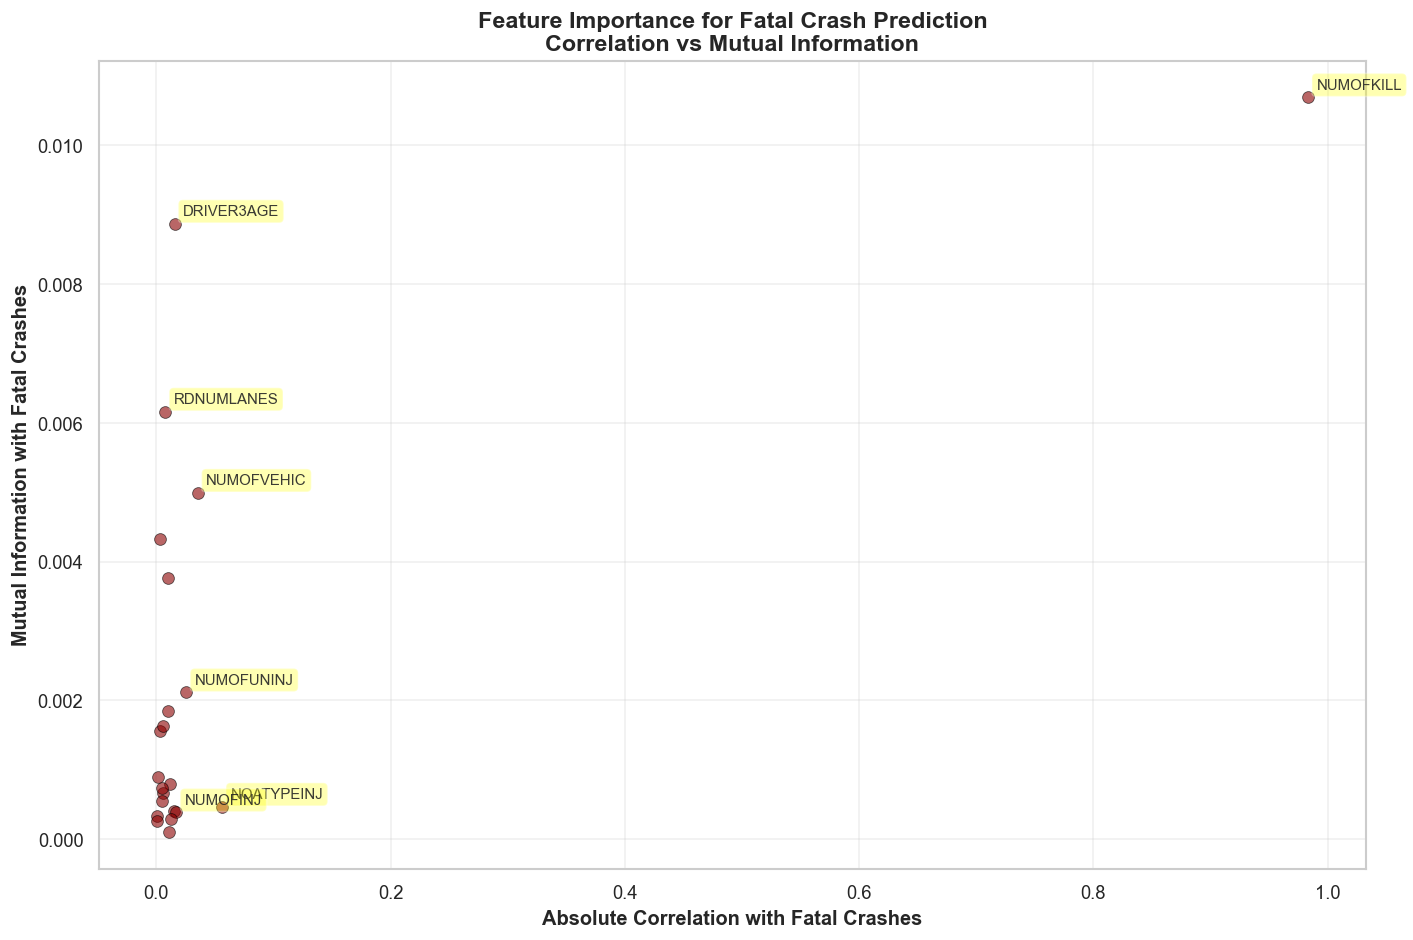


Key insights:
- Upper-right quadrant: features with both high correlation AND high MI (strongest predictors)
- High MI, low correlation: features capturing non-linear relationships with Fatal crashes
- High correlation, low MI: rare, suggests linear relationship


In [29]:
# Scatter: Correlation vs MI for Fatal prediction
fatal_comparison = pd.DataFrame({
    'Correlation': fatal_corr_abs,
    'MI': fatal_mi_series
})

plt.figure(figsize=(12, 8))
plt.scatter(fatal_comparison['Correlation'], fatal_comparison['MI'], 
           alpha=0.6, s=50, c='darkred', edgecolors='black', linewidth=0.5)

# Label top features (union of top 5 by each metric)
top_features_label = list(set(list(fatal_corr_abs.head(5).index) + list(fatal_mi_series.head(5).index)))
for feature in top_features_label:
    x = fatal_comparison.loc[feature, 'Correlation']
    y = fatal_comparison.loc[feature, 'MI']
    plt.annotate(feature, (x, y), fontsize=9, alpha=0.9, 
                xytext=(5, 5), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.xlabel('Absolute Correlation with Fatal Crashes', fontsize=12, fontweight='bold')
plt.ylabel('Mutual Information with Fatal Crashes', fontsize=12, fontweight='bold')
plt.title('Feature Importance for Fatal Crash Prediction\nCorrelation vs Mutual Information', 
         fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey insights:")
print("- Upper-right quadrant: features with both high correlation AND high MI (strongest predictors)")
print("- High MI, low correlation: features capturing non-linear relationships with Fatal crashes")
print("- High correlation, low MI: rare, suggests linear relationship")

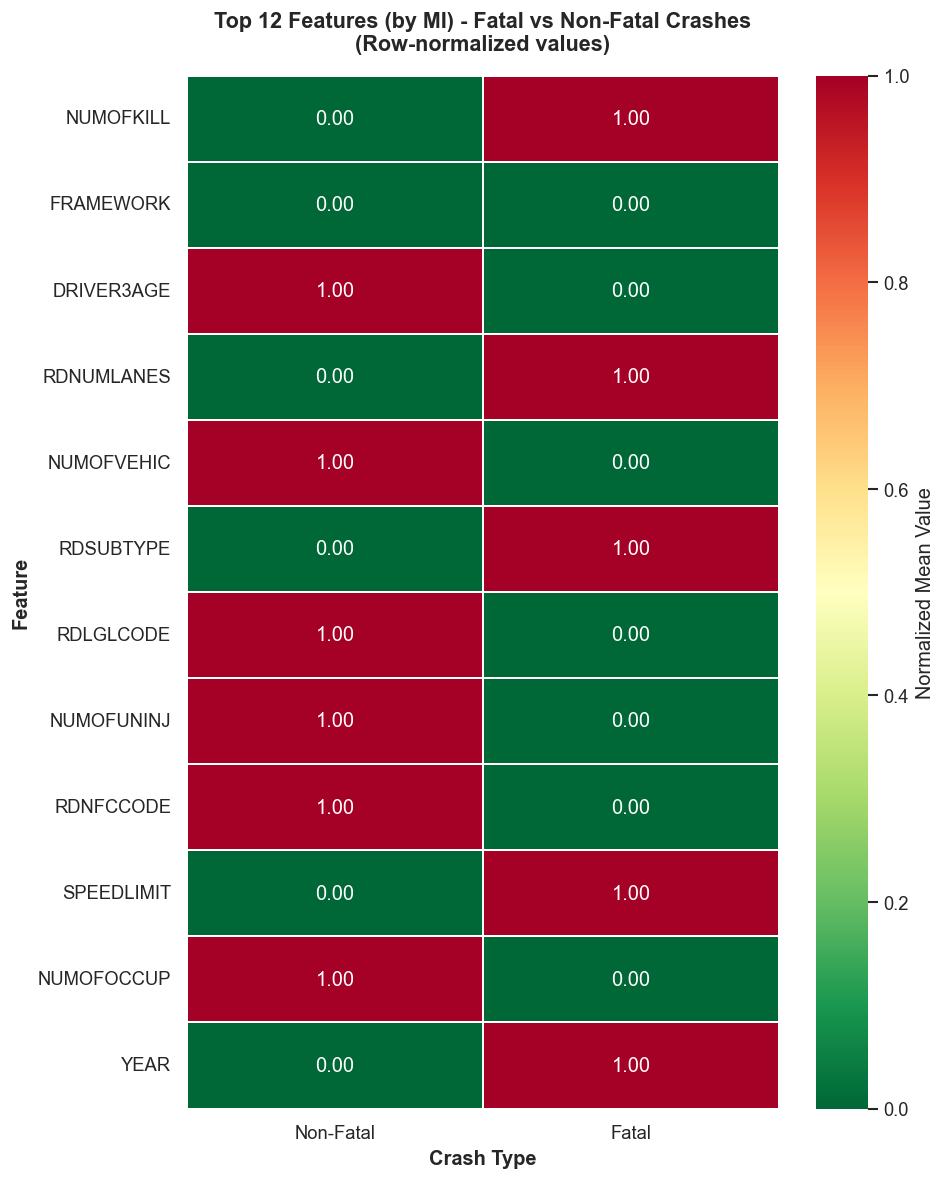


Interpretation:
- Each row is normalized: 0 = minimum value, 1 = maximum value for that feature
- Red (high values): feature tends to be higher in that crash type
- Green (low values): feature tends to be lower in that crash type


In [30]:
# Heatmap: Top features comparison (Fatal vs Non-Fatal)
top_12_features = fatal_mi_series.head(12).index.tolist()

# Create comparison matrix
heatmap_data = []
for feature in top_12_features:
    fatal_val = df[df['is_fatal'] == 1][feature].mean()
    non_fatal_val = df[df['is_fatal'] == 0][feature].mean()
    heatmap_data.append([non_fatal_val, fatal_val])

heatmap_df = pd.DataFrame(heatmap_data, 
                          index=top_12_features, 
                          columns=['Non-Fatal', 'Fatal'])

# Normalize each row to [0, 1] for better visualization
heatmap_normalized = heatmap_df.apply(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-10), axis=1
)

plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_normalized, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Normalized Mean Value'},
            linewidths=1, linecolor='white', vmin=0, vmax=1)
plt.title('Top 12 Features (by MI) - Fatal vs Non-Fatal Crashes\n(Row-normalized values)', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Crash Type', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Each row is normalized: 0 = minimum value, 1 = maximum value for that feature")
print("- Red (high values): feature tends to be higher in that crash type")
print("- Green (low values): feature tends to be lower in that crash type")

## . Quick Summary Statistics

In [23]:
summary = {
    "Total crashes": len(df),
    "Total injuries": df["NUMOFINJ"].sum(),
    "Total fatalities": df["NUMOFKILL"].sum(),
    "Hit-and-run crashes": (df["HITANDRUN"].str.contains("Yes", na=False)).sum(),
    "Alcohol-involved": (df["DRINKING"].str.contains("Yes", na=False)).sum(),
    "Pedestrian crashes": (df["PEDESTRIAN"].str.contains("Yes", na=False)).sum(),
    "Bike crashes": (df["BIKE"].str.contains("Yes", na=False)).sum(),
    "Motorcycle crashes": (df["MOTORCYCLE"].str.contains("Yes", na=False)).sum(),
    "Years covered": f"{df['YEAR'].min()} – {df['YEAR'].max()}",
    "Unique cities": df["CITY"].nunique(),
    "Unique counties": df["COUNTY"].nunique(),
}

for k, v in summary.items():
    print(f"{k:<30} {v:>10}")

Total crashes                       74309
Total injuries                      17157
Total fatalities                      109
Hit-and-run crashes                 15898
Alcohol-involved                     3261
Pedestrian crashes                   1070
Bike crashes                          926
Motorcycle crashes                    713
Years covered                  2008 – 2017
Unique cities                           1
Unique counties                         1
